LAB EXERCISE 1 — Tensor Operations
T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

ndim: 2
shape: (3, 4)

T + T:
[[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]

Transpose Shape: (4, 3)
[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]

Reshape (2,6):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]

LAB EXERCISE 2 — Norms & Cosine Similarity

Pair 1
L1 Norm: 2.0
L2 Norm: 1.4142135623730951
Cosine Similarity: 1.0

Pair 2
L1 Norm: 6.0
L2 Norm: 3.7416573867739413
Cosine Similarity: 0.7143

Pair 3
L1 Norm: 2.0
L2 Norm: 2.0
Cosine Similarity: 0.0

LAB EXERCISE 3 — Matrix Operations
Inverse(M):
[[ 0.375 -0.25 ]
 [-0.25   0.5  ]]

Trace(M): 7.0

M @ inv(M) == I ?
True

M Symmetric ?
True

P Orthogonal ?
True

LAB EXERCISE 4 — Transformations


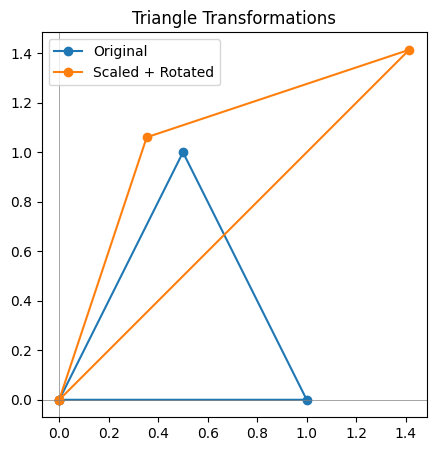


LAB EXERCISE 5 — Eigenvalues
Eigenvalues:
[5. 2.]

Eigenvectors:
[[ 0.707 -0.447]
 [ 0.707  0.894]]

Verify Cv = λv:
True

LAB EXERCISE 6 — Solve System & Embeddings
Solution x:
[1. 2.]

Rank of A2:
2

Cos(cat, dog): 0.9946
Cos(cat, car): 0.2926

cat is more similar to dog

All U4 Linear Algebra Lab Exercises Completed Successfully!


In [1]:
# ============================================================
# U4 — Linear Algebra Lab
# Complete Solutions for LAB EXERCISES 1–6
# ============================================================

import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

# ============================================================
# Helper Function
# ============================================================

def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print("="*60)
print("LAB EXERCISE 1 — Tensor Operations")
print("="*60)

T = np.arange(12).reshape(3, 4)

print("T:\n", T)

# 1. ndim and shape
print("\nndim:", T.ndim)
print("shape:", T.shape)

# 2. T + T
print("\nT + T:")
print(T + T)

# 3. Transpose and reshape
print("\nTranspose Shape:", T.T.shape)
print(T.T)

print("\nReshape (2,6):")
print(T.reshape(2, 6))


# ============================================================
# LAB EXERCISE 2
# Norms + Cosine Similarity
# ============================================================

print("\n" + "="*60)
print("LAB EXERCISE 2 — Norms & Cosine Similarity")
print("="*60)

pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),
    (np.array([1, 2, 3]), np.array([3, 2, 1])),
    (np.array([2, 0, 0]), np.array([0, 5, 0])),
]

for i, (u, v) in enumerate(pairs, start=1):
    print(f"\nPair {i}")

    print("L1 Norm:", la.norm(u, 1))
    print("L2 Norm:", la.norm(u))

    cos_sim = cosine(u, v)
    print("Cosine Similarity:", round(cos_sim, 4))

# Most Similar Pair: Pair 1 (Cosine Similarity = 1.0)

# ============================================================
# LAB EXERCISE 3
# Matrix Operations
# ============================================================

print("\n" + "="*60)
print("LAB EXERCISE 3 — Matrix Operations")
print("="*60)

M = np.array([[4., 2.],
              [2., 3.]])

P = np.array([[0., -1.],
              [1.,  0.]])

# 1. Inverse and trace
print("Inverse(M):")
print(la.inv(M))

print("\nTrace(M):", np.trace(M))

# 2. Verify identity
I = np.eye(2)

print("\nM @ inv(M) == I ?")
print(np.allclose(M @ la.inv(M), I))

# 3. Symmetric and orthogonal tests
print("\nM Symmetric ?")
print(np.allclose(M, M.T))

print("\nP Orthogonal ?")
print(np.allclose(P.T @ P, I))

# ============================================================
# LAB EXERCISE 4
# Transformations
# ============================================================

print("\n" + "="*60)
print("LAB EXERCISE 4 — Transformations")
print("="*60)

tri = np.array([
    [0, 1, 0.5],
    [0, 0, 1.0]
])

# Scaling matrix
S = np.array([
    [2.0, 0.0],
    [0.0, 0.5]
])

# Rotation matrix (45°)
theta = np.radians(45)

R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

# Apply scaling then rotation
transformed = R @ (S @ tri)

def close_loop(points):
    return np.hstack([points, points[:, :1]])

fig, ax = plt.subplots(figsize=(5,5))

ax.plot(*close_loop(tri),
        marker='o',
        label='Original')

ax.plot(*close_loop(transformed),
        marker='o',
        label='Scaled + Rotated')

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

ax.set_aspect('equal')
ax.legend()
ax.set_title("Triangle Transformations")

plt.show()

# ============================================================
# LAB EXERCISE 5
# Eigenvalues & Eigenvectors
# ============================================================

print("\n" + "="*60)
print("LAB EXERCISE 5 — Eigenvalues")
print("="*60)

C = np.array([
    [4., 1.],
    [2., 3.]
])

vals, vecs = la.eig(C)

print("Eigenvalues:")
print(vals)

print("\nEigenvectors:")
print(vecs)

# Verify first eigenvector
v = vecs[:, 0]

lhs = C @ v
rhs = vals[0] * v

print("\nVerify Cv = λv:")
print(np.allclose(lhs, rhs))

# ============================================================
# LAB EXERCISE 6
# Linear Systems + Embeddings
# ============================================================

print("\n" + "="*60)
print("LAB EXERCISE 6 — Solve System & Embeddings")
print("="*60)

A2 = np.array([
    [3., 2.],
    [1., 4.]
])

b2 = np.array([
    7.,
    9.
])

# 1. Solve system
x = la.solve(A2, b2)

print("Solution x:")
print(x)

# 2. Rank
print("\nRank of A2:")
print(la.matrix_rank(A2))

# 3. Embeddings
cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

cat_dog = cosine(cat, dog)
cat_car = cosine(cat, car)

print("\nCos(cat, dog):", round(cat_dog, 4))
print("Cos(cat, car):", round(cat_car, 4))

if cat_dog > cat_car:
    print("\ncat is more similar to dog")
else:
    print("\ncat is more similar to car")

print("\nAll U4 Linear Algebra Lab Exercises Completed Successfully!")